# 04 — Visualisations finales et prévisions futures

**Objectif** : Produire les visuels pour le portfolio et générer des prévisions sur 12 mois futurs  
**Outils** : Plotly (interactif) + Matplotlib (export PNG)

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

from utils import (
    PROVINCES, PROVINCES_FR, DATA_PROCESSED, OUTPUTS_FIGURES,
    prepare_prophet_df, compute_forecast_metrics
)

plt.style.use('seaborn-v0_8-whitegrid')
OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)
print('Imports OK')

Imports OK


In [2]:
# Charger toutes les donnees
df_all = pd.read_csv(DATA_PROCESSED / 'chomage_mensuel.csv', parse_dates=['date'])
df_comparison = pd.read_csv(DATA_PROCESSED / 'comparaison_modeles.csv')

print(f"Donnees : {df_all.shape[0]} observations")
print(f"Comparaison : {df_comparison.shape[0]} geographies")

Donnees : 6688 observations
Comparaison : 11 geographies


## 1. Graphique interactif — Historique par province (Plotly)

In [3]:
# Graphique interactif Plotly : taux de chomage par province
fig = go.Figure()

# Canada en gras
canada = df_all[df_all['geo'] == 'Canada']
fig.add_trace(go.Scatter(
    x=canada['date'], y=canada['unemployment_rate'],
    name='Canada', line=dict(color='black', width=3)
))

# Provinces
colors = px.colors.qualitative.Set3
for i, prov in enumerate(sorted(PROVINCES)):
    subset = df_all[df_all['geo'] == prov]
    fig.add_trace(go.Scatter(
        x=subset['date'], y=subset['unemployment_rate'],
        name=PROVINCES_FR.get(prov, prov),
        line=dict(color=colors[i % len(colors)], width=1.5),
        visible='legendonly'  # cache par defaut, cliquer pour afficher
    ))

# Annotations chocs
fig.add_vrect(x0='2008-10-01', x1='2009-06-01',
              fillcolor='red', opacity=0.1, annotation_text='Crise 2008')
fig.add_vrect(x0='2020-03-01', x1='2020-09-01',
              fillcolor='orange', opacity=0.1, annotation_text='COVID-19')

fig.update_layout(
    title='Taux de chômage au Canada — Données mensuelles désaisonnalisées',
    xaxis_title='',
    yaxis_title='Taux de chômage (%)',
    hovermode='x unified',
    template='plotly_white',
    height=500
)

fig.write_html(OUTPUTS_FIGURES / 'historique_interactif.html')
fig.show()
print(f"Figure interactive sauvegardee : {OUTPUTS_FIGURES / 'historique_interactif.html'}")

Figure interactive sauvegardee : /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/outputs/figures/historique_interactif.html


## 2. Prévisions futures (12 mois)

On réentraîne les deux modèles sur **toutes les données disponibles** et on projette 12 mois dans le futur.

In [4]:
# Reentrainer sur toutes les donnees et prevoir 12 mois
HORIZON_FUTURE = 12
future_forecasts = {}

for geo in ['Canada'] + sorted(PROVINCES):
    print(f"Prevision future — {PROVINCES_FR.get(geo, geo)}")
    
    # Preparer la serie complete
    full_series = (df_all[df_all['geo'] == geo]
                   .set_index('date')['unemployment_rate']
                   .asfreq('MS'))
    prophet_full = prepare_prophet_df(df_all, geo)
    
    # Lire le meilleur ordre ARIMA du tableau de comparaison
    row = df_comparison[df_comparison['Province'] == PROVINCES_FR.get(geo, geo)]
    if len(row) > 0:
        order_str = row['ARIMA_ordre'].values[0]
        order = tuple(int(x) for x in order_str.strip('()').split(', '))
    else:
        order = (1, 1, 1)  # fallback
    
    # ARIMA
    arima_model = ARIMA(full_series, order=order).fit()
    arima_fc = arima_model.get_forecast(steps=HORIZON_FUTURE)
    arima_pred = arima_fc.summary_frame(alpha=0.05)
    
    # Prophet
    prophet_model = Prophet(
        yearly_seasonality=True, weekly_seasonality=False,
        daily_seasonality=False, changepoint_prior_scale=0.05
    )
    prophet_model.fit(prophet_full)
    future_dates = prophet_model.make_future_dataframe(periods=HORIZON_FUTURE, freq='MS')
    prophet_pred = prophet_model.predict(future_dates)
    
    future_forecasts[geo] = {
        'arima_pred': arima_pred,
        'prophet_pred': prophet_pred.tail(HORIZON_FUTURE),
        'history': full_series
    }

print("\nPrevisions futures generees pour toutes les geographies.")

Prevision future — Canada


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
11:34:40 - cmdstanpy - INFO - Chain [1] start processing


11:34:40 - cmdstanpy - INFO - Chain [1] done processing


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


...

11:34:47 - cmdstanpy - INFO - Chain [1] done processing


Prevision future — Saskatchewan


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
11:34:48 - cmdstanpy - INFO - Chain [1] start processing


11:34:48 - cmdstanpy - INFO - Chain [1] done processing



Previsions futures generees pour toutes les geographies.


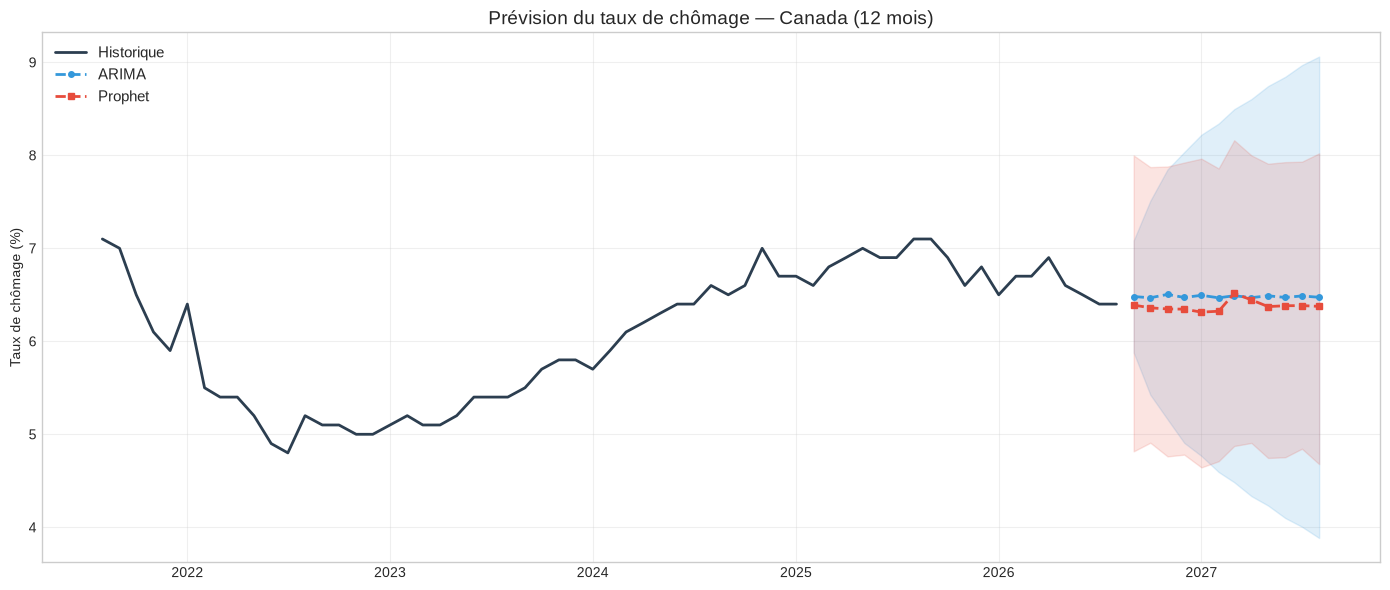

Figure principale sauvegardee : /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/outputs/figures/prevision_future_canada.png


In [5]:
# Graphique principal pour le README : prevision Canada
geo = 'Canada'
fc = future_forecasts[geo]

fig, ax = plt.subplots(figsize=(14, 6))

# Historique (5 dernieres annees)
# pandas 3 a retire Series.last() : on decoupe explicitement les cinq
# dernieres annees a partir de la derniere date observee.
historique = fc['history']
hist = historique[historique.index >= historique.index.max() - pd.DateOffset(years=5)]
ax.plot(hist.index, hist.values, color='#2c3e50', linewidth=2, label='Historique')

# ARIMA
arima_p = fc['arima_pred']
ax.plot(arima_p.index, arima_p['mean'], color='#3498db', linewidth=2,
        linestyle='--', label='ARIMA', marker='o', markersize=4)
ax.fill_between(arima_p.index, arima_p['mean_ci_lower'], arima_p['mean_ci_upper'],
                alpha=0.15, color='#3498db')

# Prophet
prophet_p = fc['prophet_pred']
ax.plot(prophet_p['ds'].values, prophet_p['yhat'].values, color='#e74c3c',
        linewidth=2, linestyle='--', label='Prophet', marker='s', markersize=4)
ax.fill_between(prophet_p['ds'].values, prophet_p['yhat_lower'].values,
                prophet_p['yhat_upper'].values, alpha=0.15, color='#e74c3c')

ax.set_title('Prévision du taux de chômage — Canada (12 mois)', fontsize=14)
ax.set_ylabel('Taux de chômage (%)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'prevision_future_canada.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure principale sauvegardee : {OUTPUTS_FIGURES / 'prevision_future_canada.png'}")

## 3. Tableau des prévisions futures

In [6]:
# Tableau : previsions a 3, 6 et 12 mois pour chaque province
forecast_table = []

for geo in ['Canada'] + sorted(PROVINCES):
    fc = future_forecasts[geo]
    arima_p = fc['arima_pred']
    prophet_p = fc['prophet_pred']
    last_actual = fc['history'].iloc[-1]
    
    for h, label in [(2, '3 mois'), (5, '6 mois'), (11, '12 mois')]:
        forecast_table.append({
            'Province': PROVINCES_FR.get(geo, geo),
            'Dernier observé (%)': round(last_actual, 1),
            'Horizon': label,
            'ARIMA (%)': round(arima_p['mean'].iloc[h], 1),
            'Prophet (%)': round(prophet_p['yhat'].iloc[h], 1),
        })

df_forecast_table = pd.DataFrame(forecast_table)
df_forecast_table.to_csv(DATA_PROCESSED / 'previsions_futures.csv', index=False)

# Afficher le tableau pour le Canada
print("=== Prévisions futures — Canada ===")
print(df_forecast_table[df_forecast_table['Province'] == 'Canada'].to_string(index=False))

print(f"\nTableau complet sauvegarde : {DATA_PROCESSED / 'previsions_futures.csv'}")

=== Prévisions futures — Canada ===
Province  Dernier observé (%) Horizon  ARIMA (%)  Prophet (%)
  Canada                  6.4  3 mois        6.5          6.3
  Canada                  6.4  6 mois        6.5          6.3
  Canada                  6.4 12 mois        6.5          6.4

Tableau complet sauvegarde : /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/data/processed/previsions_futures.csv


## 4. Composantes Prophet — Décomposition

11:34:49 - cmdstanpy - INFO - Chain [1] start processing


11:34:49 - cmdstanpy - INFO - Chain [1] done processing


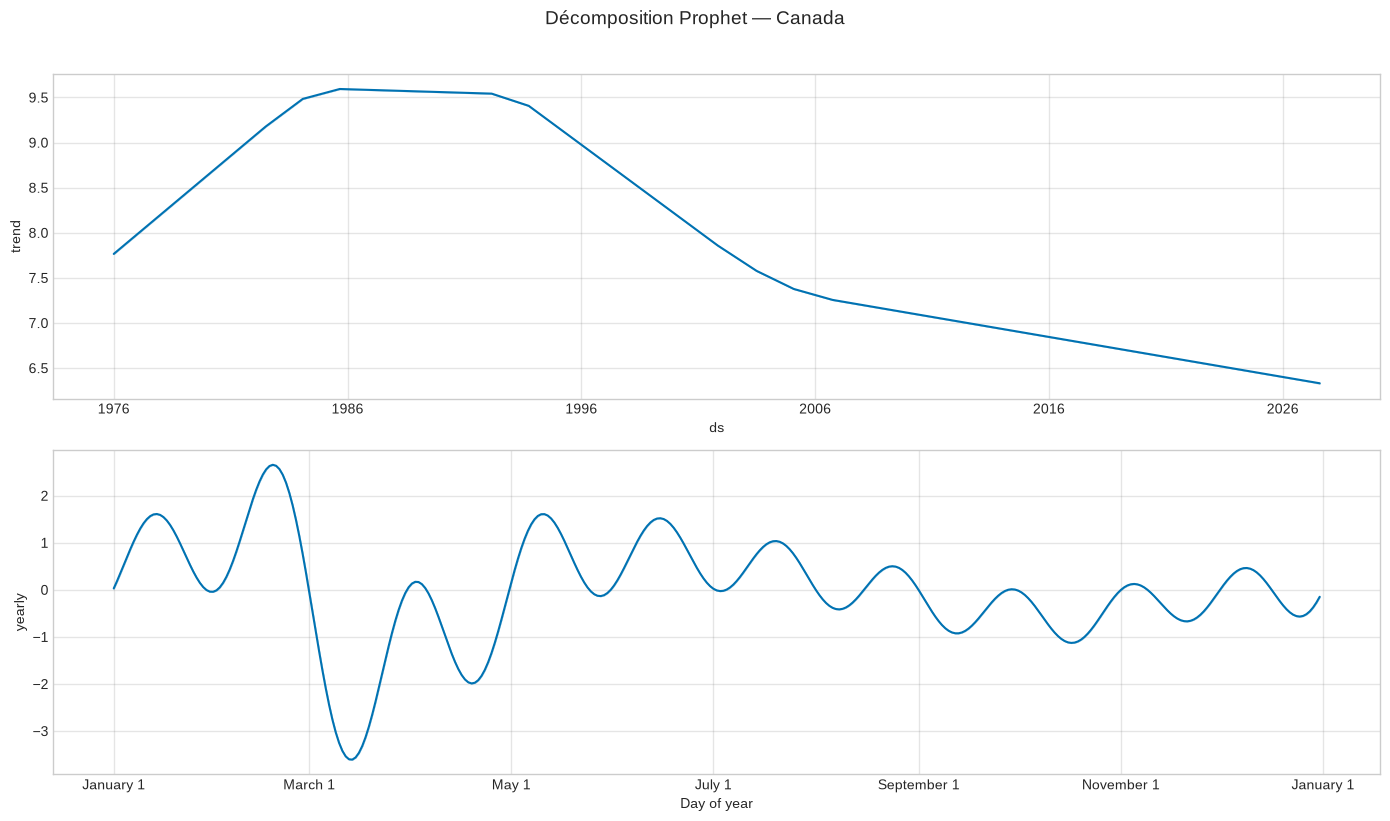

In [7]:
# Decomposition Prophet pour le Canada
# Reentrainer un modele Prophet sur les donnees completes
prophet_full_df = prepare_prophet_df(df_all, 'Canada')
model_canada = Prophet(
    yearly_seasonality=True, weekly_seasonality=False,
    daily_seasonality=False, changepoint_prior_scale=0.05
)
model_canada.fit(prophet_full_df)
future = model_canada.make_future_dataframe(periods=12, freq='MS')
forecast = model_canada.predict(future)

# Composantes
fig = model_canada.plot_components(forecast)
fig.set_size_inches(14, 8)
plt.suptitle('Décomposition Prophet — Canada', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'prophet_composantes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Heatmap interprovinciale

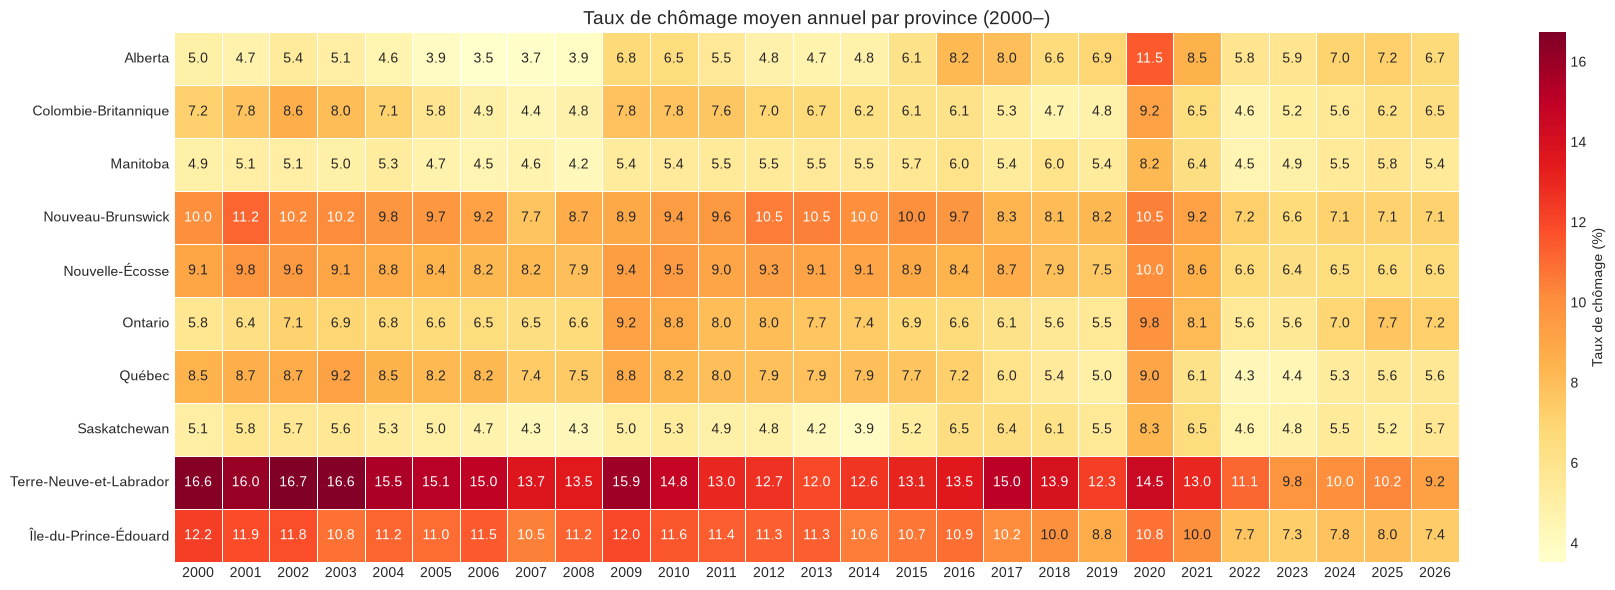

Heatmap sauvegardee : /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/outputs/figures/heatmap_provinces.png


In [8]:
# Heatmap : taux de chomage par province et annee
import seaborn as sns

df_annual = (df_all[df_all['geo'] != 'Canada']
             .assign(year=lambda x: x['date'].dt.year)
             .groupby(['geo', 'year'])['unemployment_rate']
             .mean()
             .reset_index())

df_annual['province_fr'] = df_annual['geo'].map(PROVINCES_FR)
pivot = df_annual.pivot(index='province_fr', columns='year', values='unemployment_rate')

# Garder seulement depuis 2000
pivot = pivot[[c for c in pivot.columns if c >= 2000]]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Taux de chômage (%)'})
ax.set_title('Taux de chômage moyen annuel par province (2000–)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'heatmap_provinces.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Heatmap sauvegardee : {OUTPUTS_FIGURES / 'heatmap_provinces.png'}")

## Limites et prochaines étapes

### Limites
- **Modèles univariés** : ARIMA et Prophet n'utilisent que l'historique du chômage, sans variables explicatives (PIB, emploi sectoriel, etc.)
- **Choc COVID** : Événement sans précédent qui déforme les patterns historiques et peut biaiser les prévisions
- **Données désaisonnalisées** : La saisonnalité résiduelle captée par Prophet pourrait être un artefact

### Prochaines étapes
- Ajouter des **régresseurs externes** (Leading Economic Index, offres d'emploi, taux directeur)
- Tester **NeuralProphet** pour capturer des non-linéarités
- Implémenter une **cross-validation temporelle** (time series split) pour une évaluation plus robuste
- Déployer un **dashboard Streamlit** avec mise à jour automatique des données

---
*Projet réalisé dans le cadre du portfolio Données Ouvertes Canada.*  
*Licence des données : Licence du gouvernement ouvert — Canada*